In [25]:

import pandas as pd
import numpy as np

# Load Data
df = pd.read_excel('nationaldatabaseofchildcareprices.xlsx')

print("Loaded dataset with shape:", df.shape)
print("\nFirst few rows:")
display(df.head(5))

# Clean Column Names
df.columns = (
    df.columns.str.strip()
              .str.replace(" ", "_")
              .str.replace(r"[^\w\s]", "", regex=True)
)

# Convert Dollar Columns to Float
money_cols = [col for col in df.columns 
              if df[col].dtype == 'object' and df[col].astype(str).str.contains(r'\$').any()]

for col in money_cols:
    df[col] = df[col].replace(r'[\$,]', '', regex=True).astype(float)

# Handle Missing Values
num_cols = df.select_dtypes(include=[np.number]).columns
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

print("Dataset cleaned and stored in memory.")

# Summary Statistics
summary_cols = ['MCInfant', 'MCToddler', 'MCPreschool', 'MHI']
print("\nSummary Statistics for Childcare Costs and Household Income:")
display(df[summary_cols].describe().round(2))

# Affordability Metrics
affordability_metrics = pd.DataFrame({
    'InfantCostPctIncome': (df['MCInfant'] * 12) / df['MHI'] * 100,
    'ToddlerCostPctIncome': (df['MCToddler'] * 12) / df['MHI'] * 100,
    'PreschoolCostPctIncome': (df['MCPreschool'] * 12) / df['MHI'] * 100
})

# Add metrics all at once and defragment
df = pd.concat([df, affordability_metrics], axis=1).copy()

afford_cols = ['InfantCostPctIncome', 'ToddlerCostPctIncome', 'PreschoolCostPctIncome']
print("\nChildcare Cost as % of Household Income:")
display(df[afford_cols].describe().round(2))

# Correlation Analysis
print("\nCorrelation between Childcare Costs and Median Household Income:")
corr_matrix = df[['MCInfant', 'MCToddler', 'MCPreschool', 'MHI']].corr()
display(corr_matrix[['MHI']].drop('MHI').round(2))

# Top 10 Counties with Highest Infant Childcare Burden
top_burden = df[['State_Name', 'County_Name', 'MCInfant', 'MHI', 'InfantCostPctIncome']] \
              .sort_values(by='InfantCostPctIncome', ascending=False) \
              .head(10)

print("\nTop 10 Counties with Highest Infant Childcare Burden:")
display(top_burden.round(2))

# Counties with Affordable Infant Care (<7% of income)
affordable_counties = df[df['InfantCostPctIncome'] < 7]
print(f"\nNumber of Counties Where Infant Care is Considered Affordable (<7%): {affordable_counties.shape[0]}")

# Female Labor Force Participation
flfp_col = 'FLFPR_20to64_Under6'
if flfp_col in df.columns:
    avg_flfpr = df[flfp_col].mean()
    print(f"\nAverage Female Labor Force Participation (Ages 20–64 with Children Under 6): {avg_flfpr:.2f}%")
else:
    print(f"\nColumn '{flfp_col}' was not found in dataset.")

Loaded dataset with shape: (34567, 227)

First few rows:


,State_Name,State_Abbreviation,County_Name,County_FIPS_Code,StudyYear,UNR_16,FUNR_16,MUNR_16,UNR_20to64,FUNR_20to64,...,MFCCToddler,MFCCToddler_flag,MFCCPreschool,MFCCPreschool_flag,_75FCCInfant,_75FCCInfant_flag,_75FCCToddler,_75FCCToddler_flag,_75FCCPreschool,_75FCCPreschool_flag
0,Alabama,AL,Autauga County,1001,2008,5.42,4.41,6.32,4.6,3.5,...,83.45,3.0,81.40,1.0,97.4,1.0,97.4,3.0,95.0,1.0
1,Alabama,AL,Autauga County,1001,2009,5.93,5.72,6.11,4.8,4.6,...,87.39,3.0,85.68,1.0,102.0,1.0,102.0,3.0,100.0,1.0
2,Alabama,AL,Autauga County,1001,2010,6.21,5.57,6.78,5.1,4.6,...,91.33,3.0,89.96,1.0,106.6,1.0,106.6,3.0,105.0,1.0
3,Alabama,AL,Autauga County,1001,2011,7.55,8.13,7.03,6.2,6.3,...,95.28,3.0,94.25,1.0,111.2,1.0,111.2,3.0,110.0,1.0
4,Alabama,AL,Autauga County,1001,2012,8.60,8.88,8.29,6.7,6.4,...,99.22,3.0,98.53,1.0,115.8,1.0,115.8,3.0,115.0,1.0


Dataset cleaned and stored in memory.

Summary Statistics for Childcare Costs and Household Income:


,MCInfant,MCToddler,MCPreschool,MHI
count,34567.00,34567.00,34567.00,34567.00
mean,142.38,127.47,119.62,46432.00
std,44.69,36.43,32.07,12457.05
min,27.73,21.54,21.54,18528.56
25%,120.00,109.62,103.62,38250.50
50%,134.50,120.99,113.99,44438.00
75%,150.00,135.00,125.00,52078.39
max,470.00,419.00,385.00,136268.00



Childcare Cost as % of Household Income:


...


Correlation between Childcare Costs and Median Household Income:


,MHI
MCInfant,0.53
MCToddler,0.53
MCPreschool,0.54



Top 10 Counties with Highest Infant Childcare Burden:


,State_Name,County_Name,MCInfant,MHI,InfantCostPctIncome
20139,New York,Bronx County,397.70,38085.0,12.53
32901,Washington,Whitman County,369.69,35578.0,12.47
32593,Washington,Ferry County,369.69,37542.0,11.82
32758,Washington,Pacific County,369.69,39418.0,11.25
32747,Washington,Okanogan County,369.69,39665.0,11.18
32769,Washington,Pend Oreille County,369.69,40070.0,11.07
32759,Washington,Pacific County,339.29,37684.0,10.80
32560,Washington,Columbia County,369.69,41071.0,10.80
32902,Washington,Whitman County,322.96,36631.0,10.58
32846,Washington,Stevens County,369.69,42111.0,10.53



Number of Counties Where Infant Care is Considered Affordable (<7%): 34216

Average Female Labor Force Participation (Ages 20–64 with Children Under 6): 68.82%


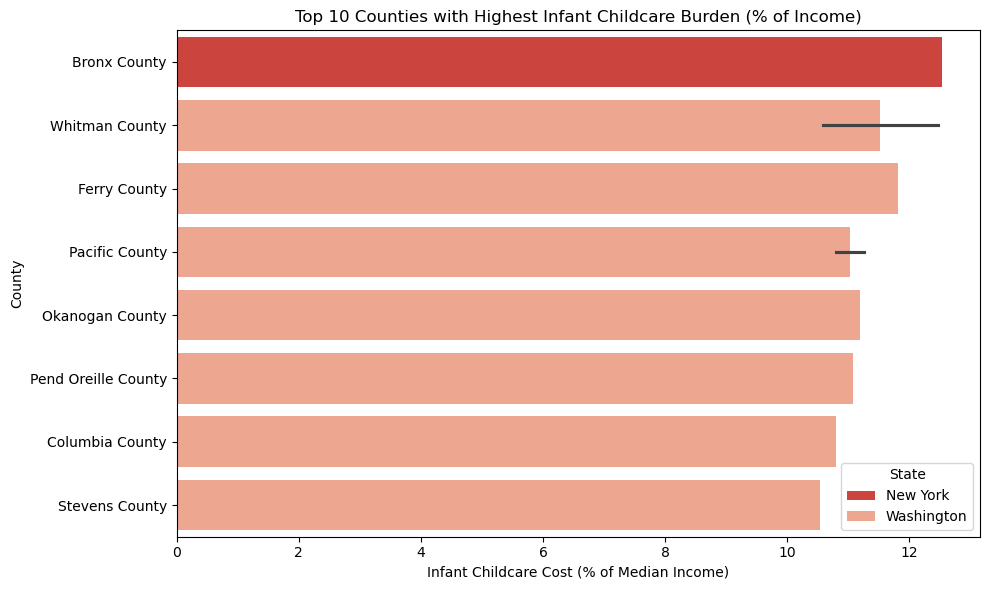

In [27]:

import seaborn as sns
import matplotlib.pyplot as plt

# Top 10 Counties with highest infant childcare
top10 = df[['State_Name', 'County_Name', 'InfantCostPctIncome']] \
            .sort_values(by='InfantCostPctIncome', ascending=False).head(10)

# Plot the bar chart
plt.figure(figsize=(10,6))
sns.barplot(data=top10, 
            x='InfantCostPctIncome', 
            y='County_Name', 
            hue='State_Name', 
            dodge=False, palette='Reds_r')

plt.title('Top 10 Counties with Highest Infant Childcare Burden (% of Income)')
plt.xlabel('Infant Childcare Cost (% of Median Income)')
plt.ylabel('County')
plt.legend(title='State')
plt.tight_layout()
plt.show()

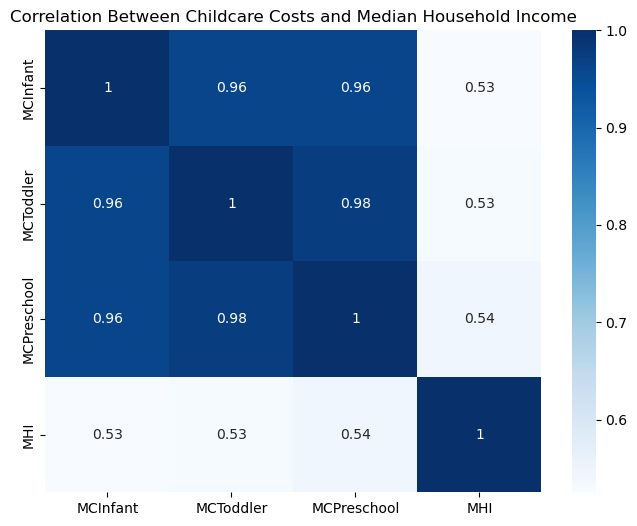

In [29]:
# Plot the heatmap for infant, toddler, preschool, and household income
plt.figure(figsize=(8, 6))
sns.heatmap(df[['MCInfant', 'MCToddler', 'MCPreschool', 'MHI']].corr(), annot=True, cmap='Blues')
plt.title('Correlation Between Childcare Costs and Median Household Income')
plt.show()

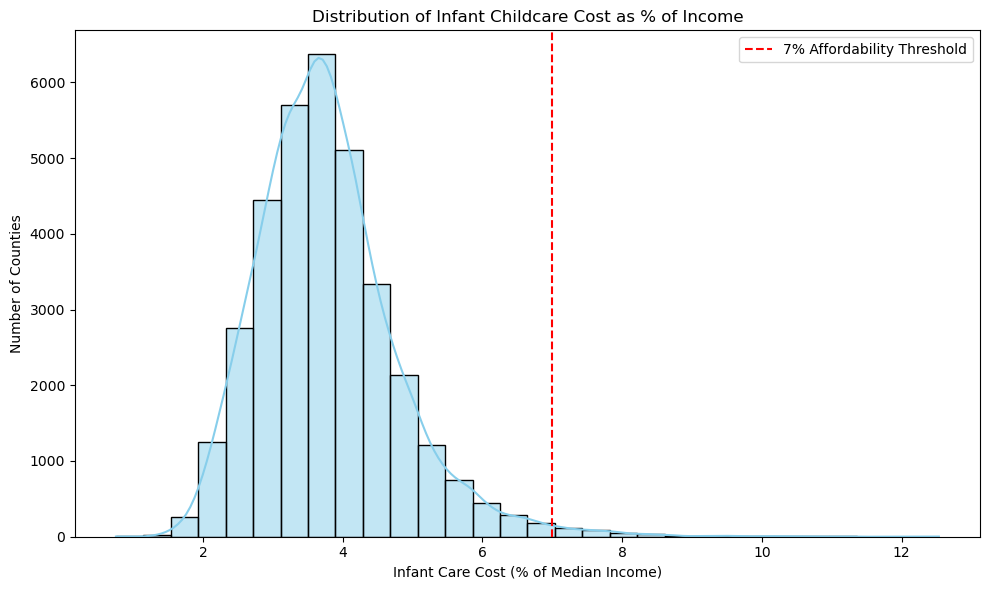

In [31]:
# Plot the histogram with the line being at 7%
plt.figure(figsize=(10,6))
sns.histplot(df['InfantCostPctIncome'], bins=30, kde=True, color='skyblue')
plt.axvline(7, color='red', linestyle='--', label='7% Affordability Threshold')
plt.title('Distribution of Infant Childcare Cost as % of Income')
plt.xlabel('Infant Care Cost (% of Median Income)')
plt.ylabel('Number of Counties')
plt.legend()
plt.tight_layout()
plt.show()

C:\Users\jerem\AppData\Local\Temp\ipykernel_7956\4117025399.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df[df['State_Name'].isin(top_states)],


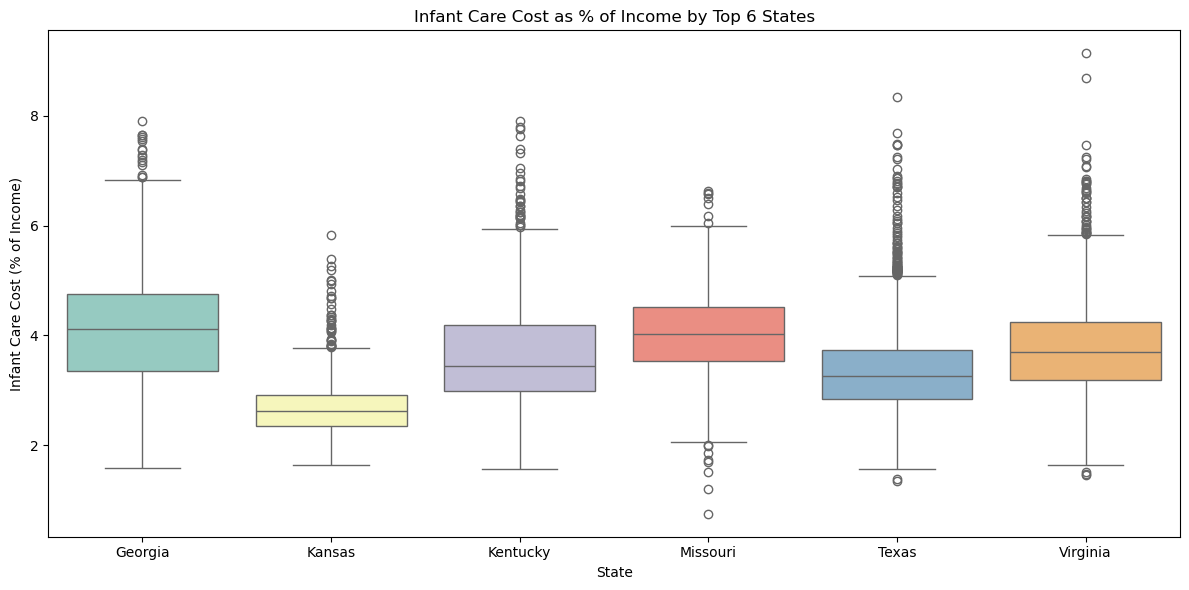

In [33]:

# Using State_Name directly
plt.figure(figsize=(12,6))
top_states = df['State_Name'].value_counts().head(6).index
sns.boxplot(data=df[df['State_Name'].isin(top_states)], 
            x='State_Name', 
            y='InfantCostPctIncome', 
            palette='Set3')

plt.title('Infant Care Cost as % of Income by Top 6 States')
plt.xlabel('State')
plt.ylabel('Infant Care Cost (% of Income)')
plt.tight_layout()
plt.show()

Yearly averages:
    StudyYear           MHI    MCInfant   MCToddler  MCPreschool
0        2008  43464.596467  134.032352  119.888845   112.502584
1        2009  43462.074133  134.035164  119.535374   112.894015
2        2010  44270.299077  134.041492  119.427171   112.981473
3        2011  45292.073497  136.526376  121.906688   114.741607
4        2012  45644.414254  138.818416  124.306682   116.491034
5        2013  45937.120904  142.634114  127.583000   119.823684
6        2014  46543.760662  144.677263  129.528230   121.821025
7        2015  46834.982177  148.290691  132.675576   124.204176
8        2016  47973.225971  146.557352  131.577187   123.420376
9        2017  49754.163908  151.173555  135.995121   126.439981
10       2018  51577.714405  155.450127  139.743994   130.462667


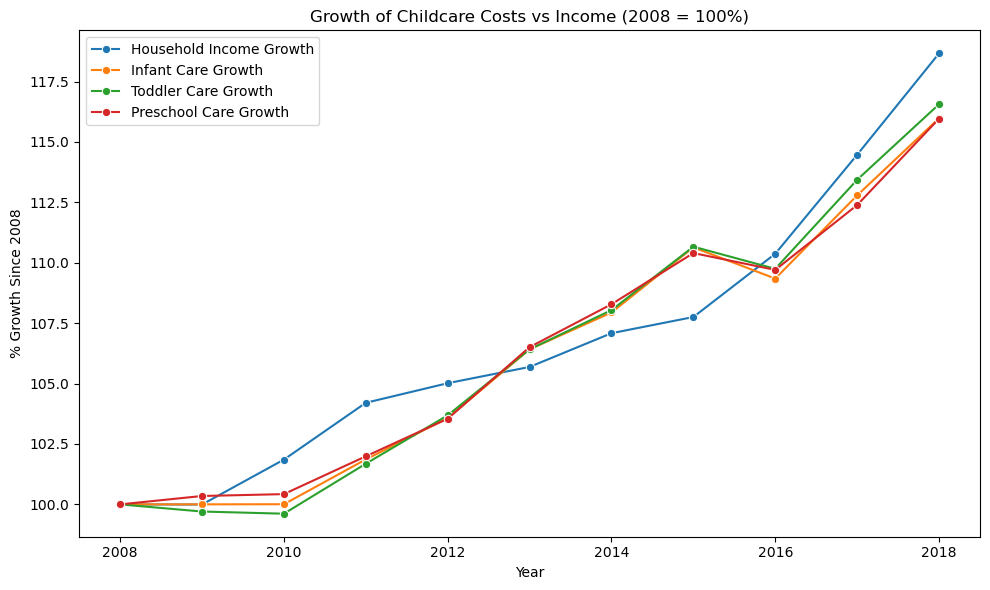

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by StudyYear and average relevant columns
yearly_trends = df.groupby('StudyYear')[['MHI', 'MCInfant', 'MCToddler', 'MCPreschool']].mean().reset_index()

# Round for neatness
yearly_trends = yearly_trends.round(6)

print("Yearly averages:")
print(yearly_trends)

# Base year for normalization
base_year = 2008
base_vals = yearly_trends[yearly_trends['StudyYear'] == base_year]

# Normalize to percent of 2008 values (assuming monthly costs multiplied by 12 for annual)
yearly_trends['MHI_pct'] = (yearly_trends['MHI'] / base_vals['MHI'].values[0]) * 100
yearly_trends['Infant_pct'] = (yearly_trends['MCInfant'] * 12) / (base_vals['MCInfant'].values[0] * 12) * 100
yearly_trends['Toddler_pct'] = (yearly_trends['MCToddler'] * 12) / (base_vals['MCToddler'].values[0] * 12) * 100
yearly_trends['Preschool_pct'] = (yearly_trends['MCPreschool'] * 12) / (base_vals['MCPreschool'].values[0] * 12) * 100

# Plotting the growth trends
plt.figure(figsize=(10,6))
sns.lineplot(data=yearly_trends, x='StudyYear', y='MHI_pct', label='Household Income Growth', marker='o')
sns.lineplot(data=yearly_trends, x='StudyYear', y='Infant_pct', label='Infant Care Growth', marker='o')
sns.lineplot(data=yearly_trends, x='StudyYear', y='Toddler_pct', label='Toddler Care Growth', marker='o')
sns.lineplot(data=yearly_trends, x='StudyYear', y='Preschool_pct', label='Preschool Care Growth', marker='o')

plt.title('Growth of Childcare Costs vs Income (2008 = 100%)')
plt.ylabel('% Growth Since 2008')
plt.xlabel('Year')
plt.legend()
plt.tight_layout()
plt.show()

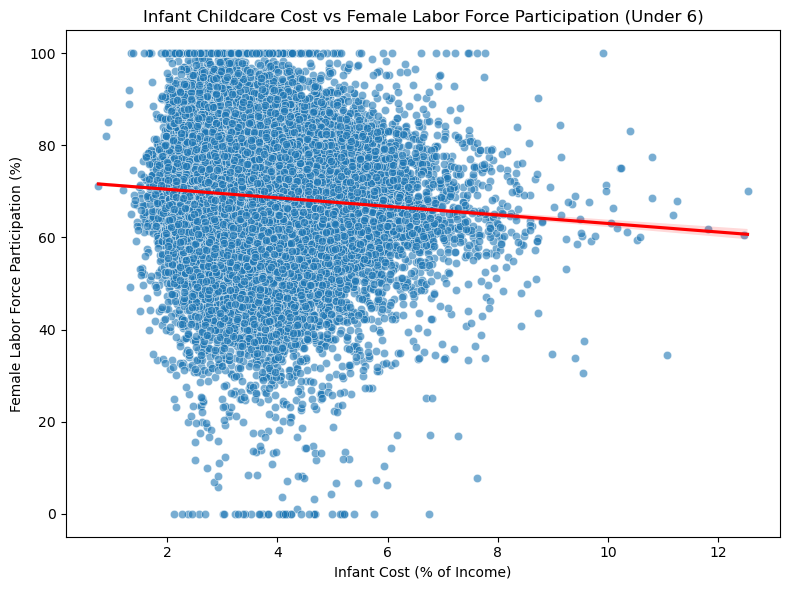

In [39]:
# Plot the scatter plot with regression line for femail labor force
if 'FLFPR_20to64_Under6' in df.columns:
    plt.figure(figsize=(8,6))
    sns.scatterplot(data=df, x='InfantCostPctIncome', y='FLFPR_20to64_Under6', alpha=0.6)
    sns.regplot(data=df, x='InfantCostPctIncome', y='FLFPR_20to64_Under6', scatter=False, color='red')
    plt.title('Infant Childcare Cost vs Female Labor Force Participation (Under 6)')
    plt.xlabel('Infant Cost (% of Income)')
    plt.ylabel('Female Labor Force Participation (%)')
    plt.tight_layout()
    plt.show()
else:
    print("Column 'FLFPR_20to64_Under6' not available in dataset.")

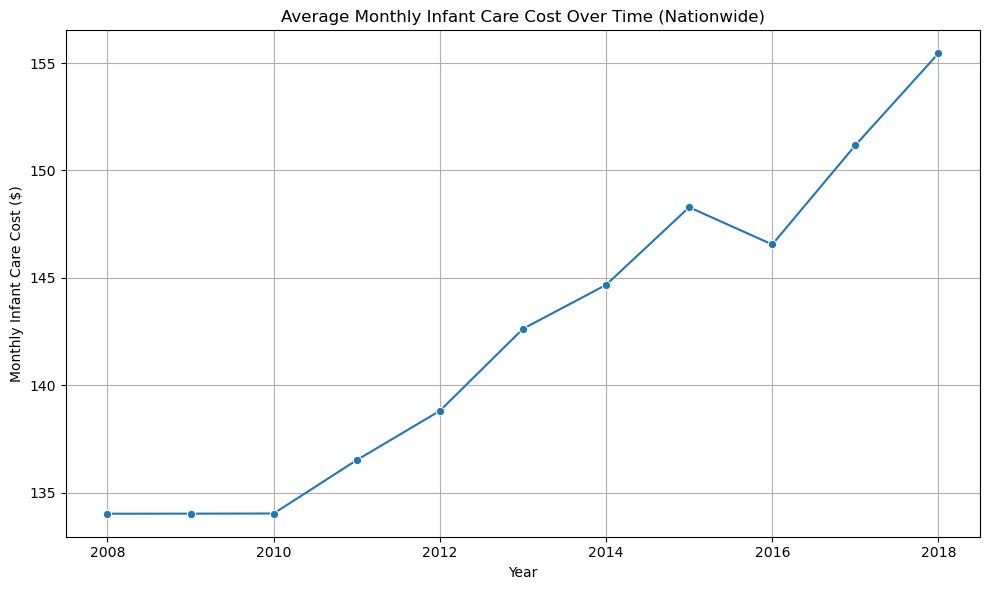

In [41]:

import matplotlib.pyplot as plt
import seaborn as sns

# Ensure StudyYear and MCInfant exist
df_year_state = df[['StudyYear', 'State_Name', 'MCInfant']].dropna()

# Group by year to get national trend
avg_infant_cost_by_year = df_year_state.groupby('StudyYear')['MCInfant'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.lineplot(data=avg_infant_cost_by_year, x='StudyYear', y='MCInfant', marker='o')
plt.title('Average Monthly Infant Care Cost Over Time (Nationwide)')
plt.xlabel('Year')
plt.ylabel('Monthly Infant Care Cost ($)')
plt.grid(True)
plt.tight_layout()
plt.show()

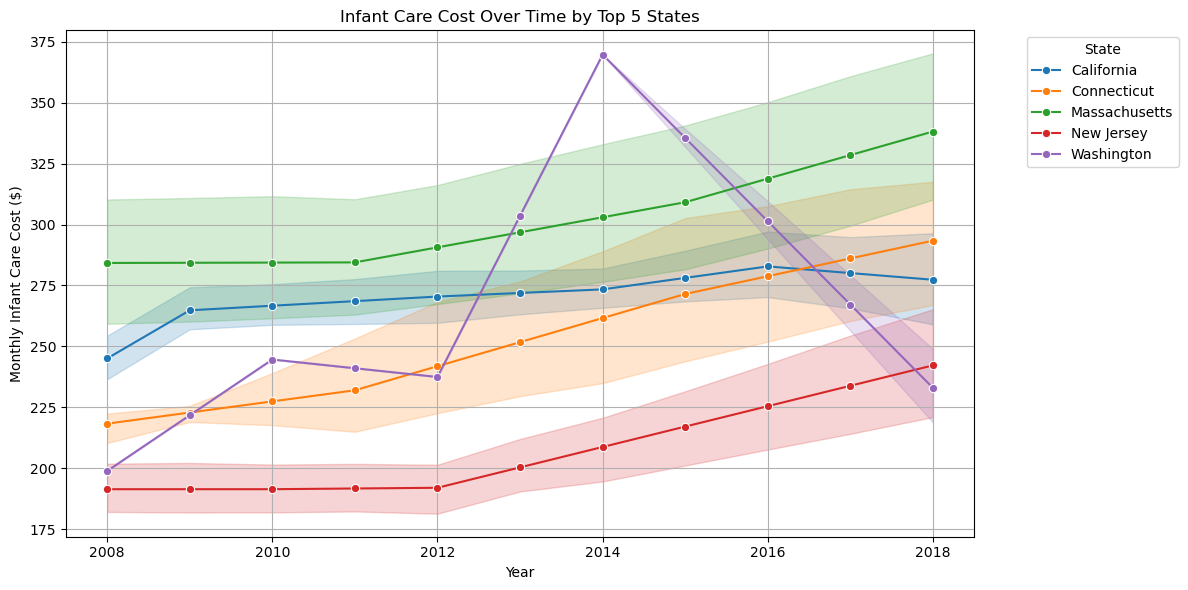

In [43]:

# Compute average infant cost by state
top_states = df.groupby('State_Name')['MCInfant'].mean().sort_values(ascending=False).head(5).index.tolist()

# Filter for top states and drop missing
df_top_states = df[df['State_Name'].isin(top_states)][['StudyYear', 'State_Name', 'MCInfant']].dropna()

plt.figure(figsize=(12,6))
sns.lineplot(data=df_top_states, x='StudyYear', y='MCInfant', hue='State_Name', marker='o')
plt.title('Infant Care Cost Over Time by Top 5 States')
plt.xlabel('Year')
plt.ylabel('Monthly Infant Care Cost ($)')
plt.legend(title='State', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

C:\Users\jerem\AppData\Local\Temp\ipykernel_7956\1109270742.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=state_burden,


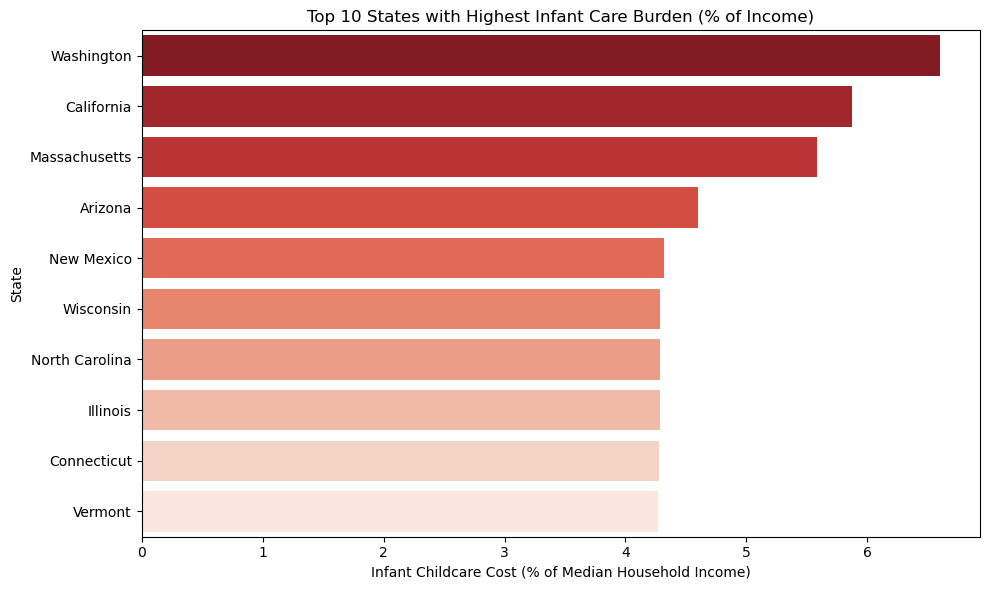

In [45]:

import matplotlib.pyplot as plt
import seaborn as sns

# Group by state and calculate average infant cost burden
state_burden = df.groupby('State_Name')['InfantCostPctIncome'].mean().sort_values(ascending=False).head(10).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=state_burden,
            x='InfantCostPctIncome',
            y='State_Name',
            palette='Reds_r')

plt.title('Top 10 States with Highest Infant Care Burden (% of Income)')
plt.xlabel('Infant Childcare Cost (% of Median Household Income)')
plt.ylabel('State')
plt.tight_layout()
plt.show()

In [47]:

import pandas as pd
import numpy as np

# Load the Excel File into raw DataFrame
df_raw = pd.read_excel('nationaldatabaseofchildcareprices.xlsx')

# Clean Column Names on a copy (to keep df_raw intact)
df_clean = df_raw.copy()
df_clean.columns = (
    df_clean.columns.str.strip()
                    .str.replace(" ", "_")
                    .str.replace(r"[^\w\s]", "", regex=True)
)

# Convert Dollar Columns to Float
money_cols = [col for col in df_clean.columns 
              if df_clean[col].dtype == 'object' and df_clean[col].astype(str).str.contains(r'\$').any()]

for col in money_cols:
    df_clean[col] = df_clean[col].replace(r'[\$,]', '', regex=True).astype(float)

# Handle Missing Numeric Values
num_cols = df_clean.select_dtypes(include=[np.number]).columns
df_clean[num_cols] = df_clean[num_cols].fillna(df_clean[num_cols].median())

# Create Affordability Metrics
df_clean['InfantCostPctIncome'] = (df_clean['MCInfant'] * 12) / df_clean['MHI'] * 100
df_clean['ToddlerCostPctIncome'] = (df_clean['MCToddler'] * 12) / df_clean['MHI'] * 100
df_clean['PreschoolCostPctIncome'] = (df_clean['MCPreschool'] * 12) / df_clean['MHI'] * 100

df_clean = df_clean.copy()  # defragment in memory

# Round metrics for display
df_clean['InfantCostPctIncome'] = df_clean['InfantCostPctIncome'].round(2)
df_clean['ToddlerCostPctIncome'] = df_clean['ToddlerCostPctIncome'].round(2)
df_clean['PreschoolCostPctIncome'] = df_clean['PreschoolCostPctIncome'].round(2)

# Create Reshaped Version for Power BI Slicer Support
df_long = pd.melt(
    df_clean,
    id_vars=['State_Name', 'County_Name', 'StudyYear', 'MHI'],
    value_vars=['MCInfant', 'MCToddler', 'MCPreschool'],
    var_name='Care_Type',
    value_name='Monthly_Cost'
)

# Add Cost as % of Income dynamically (simplified)
df_long['CostPctIncome'] = (df_long['Monthly_Cost'] * 12) / df_long['MHI'] * 100
df_long['CostPctIncome'] = df_long['CostPctIncome'].round(2)

# Export Cleaned Data without overwriting original raw data
df_clean.to_csv('childcare_cleaned_full.csv', index=False)
df_long.to_csv('childcare_cleaned_long.csv', index=False)

print("✅ Cleaned files exported:\n- Full: childcare_cleaned_full.csv\n- Long format (for Power BI slicers): childcare_cleaned_long.csv")

C:\Users\jerem\AppData\Local\Temp\ipykernel_7956\3045261956.py:27: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['InfantCostPctIncome'] = (df_clean['MCInfant'] * 12) / df_clean['MHI'] * 100
C:\Users\jerem\AppData\Local\Temp\ipykernel_7956\3045261956.py:28: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df_clean['ToddlerCostPctIncome'] = (df_clean['MCToddler'] * 12) / df_clean['MHI'] * 100
C:\Users\jerem\AppData\Local\Temp\ipykernel_7956\3045261956.py:29: PerformanceWarning: DataFrame is highly fragmented.  This is usuall

✅ Cleaned files exported:
- Full: childcare_cleaned_full.csv
- Long format (for Power BI slicers): childcare_cleaned_long.csv
